In [2]:
import matplotlib.pyplot as plt
import numpy as np

Square Lattice to compare to triangle lattice

In [3]:
def create_Hamiltonian(num_qubits, J, J_parallel, phi=0):
    nn_coupling = [J if i % 2 == 0 else 0 for i in range(num_qubits-1)]
    nnn_coupling = [J_parallel * np.exp(-1j*phi) if i % 2 == 0 else J_parallel for i in range(num_qubits-2)]

    return np.diag(nn_coupling, 1) + np.diag(nn_coupling, -1) + np.diag(nnn_coupling, 2) + np.diag(np.conjugate(nnn_coupling), -2)

def get_eigenvalues_and_vectors(H):
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    sorted_indices = np.argsort(eigenvalues)
    return eigenvalues[sorted_indices], eigenvectors[:, sorted_indices]

def analyze_ground_state(ground_state, current_operators, bond_operators):
    currents = np.real([ground_state.conj().T @ current_op @ ground_state for current_op in current_operators])
    bond_values = np.real([ground_state.conj().T @ bond_op @ ground_state for bond_op in bond_operators])
    return currents, bond_values

0 flux eigenvalues: [-2.99620666e+00 -2.98484102e+00 -2.96594620e+00 -2.93959387e+00
 -2.90588400e+00 -2.86494446e+00 -2.81693054e+00 -2.76202439e+00
 -2.70043427e+00 -2.63239382e+00 -2.55816115e+00 -2.47801783e+00
 -2.39226789e+00 -2.30123660e+00 -2.20526927e+00 -2.10472995e+00
 -2.00000000e+00 -1.89147671e+00 -1.77957175e+00 -1.66470960e+00
 -1.54732598e+00 -1.42786617e+00 -1.30678331e+00 -1.18453672e+00
 -1.06159012e+00 -9.96206657e-01 -9.84841019e-01 -9.65946199e-01
 -9.39593872e-01 -9.38409883e-01 -9.05884001e-01 -8.64944459e-01
 -8.16930544e-01 -8.15463281e-01 -7.62024389e-01 -7.00434271e-01
 -6.93216690e-01 -6.32393825e-01 -5.72133834e-01 -5.58161149e-01
 -4.78017834e-01 -4.52674020e-01 -3.92267892e-01 -3.35290401e-01
 -3.01236600e-01 -2.20428253e-01 -2.05269273e-01 -1.08523288e-01
 -1.04729946e-01 -3.59393054e-17  3.29140638e-16  1.04729946e-01
  1.08523288e-01  2.05269273e-01  2.20428253e-01  3.01236600e-01
  3.35290401e-01  3.92267892e-01  4.52674020e-01  4.78017834e-01
  5.5

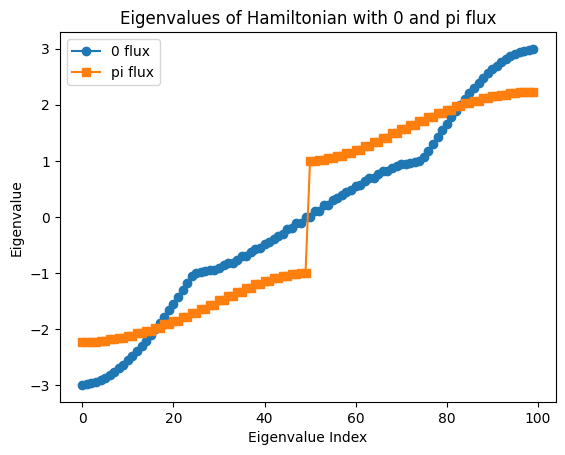

pi flux eigenvalues: [-2.23267575 -2.23267575 -2.22251971 -2.22251971 -2.20566191 -2.20566191
 -2.18220631 -2.18220631 -2.15229966 -2.15229966 -2.11613275 -2.11613275
 -2.07394228 -2.07394228 -2.02601331 -2.02601331 -1.97268262 -1.97268262
 -1.91434312 -1.91434312 -1.85144975 -1.85144975 -1.78452703 -1.78452703
 -1.71417907 -1.71417907 -1.64110228 -1.64110228 -1.56610154 -1.56610154
 -1.49011015 -1.49011015 -1.41421356 -1.41421356 -1.33967561 -1.33967561
 -1.26796376 -1.26796376 -1.20076594 -1.20076594 -1.13998497 -1.13998497
 -1.08768996 -1.08768996 -1.046      -1.046      -1.01688436 -1.01688436
 -1.00189488 -1.00189488  1.00189488  1.00189488  1.01688436  1.01688436
  1.046       1.046       1.08768996  1.08768996  1.13998497  1.13998497
  1.20076594  1.20076594  1.26796376  1.26796376  1.33967561  1.33967561
  1.41421356  1.41421356  1.49011015  1.49011015  1.56610154  1.56610154
  1.64110228  1.64110228  1.71417907  1.71417907  1.78452703  1.78452703
  1.85144975  1.85144975  1.91

In [4]:
J = -1
J_parallel = J


num_qubits = 100

H_0 = create_Hamiltonian(num_qubits, J, J_parallel, 0)
eigenvalues_0, eigenvectors_0 = get_eigenvalues_and_vectors(H_0)
print(f'0 flux eigenvalues: {eigenvalues_0}')

H_pi = create_Hamiltonian(num_qubits, J, -J_parallel, np.pi)
eigenvalues_pi, eigenvectors_pi = get_eigenvalues_and_vectors(H_pi)

plt.plot(eigenvalues_0, marker='o', label='0 flux')
plt.plot(eigenvalues_pi, marker='s', label='pi flux')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Hamiltonian with 0 and pi flux')
plt.legend()
plt.show()

print(f'pi flux eigenvalues: {eigenvalues_pi}')


In [5]:
bond_operators = []
for i in range(num_qubits//2):
    bond_op = np.zeros((num_qubits, num_qubits))
    bond_op[2*i, 2*i+1] = 1
    bond_op[2*i+1, 2*i] = 1
    bond_operators.append(bond_op)

current_operators = []
for i in range(num_qubits//2):
    current_op = np.zeros((num_qubits, num_qubits), dtype=complex)
    current_op[2*i, 2*i+1] = -1j
    current_op[2*i+1, 2*i] = 1j
    current_operators.append(current_op)

In [6]:
ground_state_0 = eigenvectors_0[:, 0]
currents_0, bond_values_0 = analyze_ground_state(ground_state_0, current_operators, bond_operators)

ground_state_pi = eigenvectors_pi[:, 0]
currents_pi, bond_values_pi = analyze_ground_state(ground_state_pi, current_operators, bond_operators)

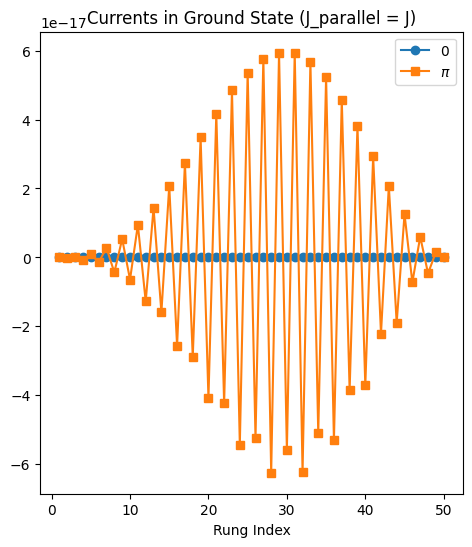

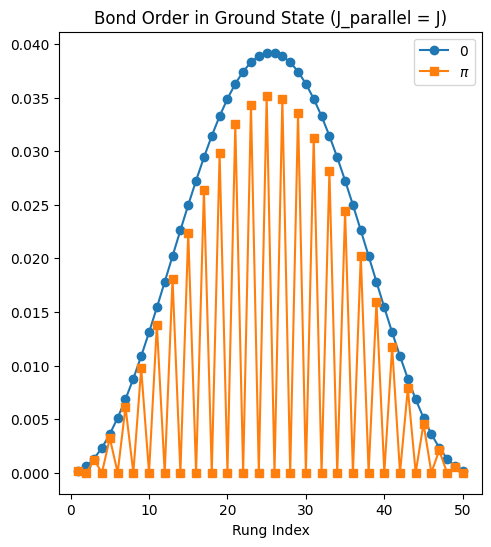

In [7]:
rungs = range(1, num_qubits//2+1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

plt.plot(rungs, currents_0, marker='o', label='0')
plt.plot(rungs, currents_pi, marker='s', label='$\pi$')

plt.title('Currents in Ground State (J_parallel = J)')
plt.xlabel('Rung Index')
plt.legend()
plt.show()



plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(rungs, bond_values_0, marker='o', label='0')
plt.plot(rungs, bond_values_pi, marker='s', label='$\pi$')

# plt.plot(rungs, [0]*len(rungs), color='gray', linestyle='', marker='o', ms=8)

k_star = 2 * np.arccos(1/4)
# k_star = np.pi
x_values = np.linspace(0, len(rungs), 1001)

# plt.plot(x_values, np.max(bond_values_pi)*np.sin(k_star * x_values), label='sin(k* rungs)', linestyle='--')

plt.title('Bond Order in Ground State (J_parallel = J)')
plt.xlabel('Rung Index')
plt.legend()
plt.show()

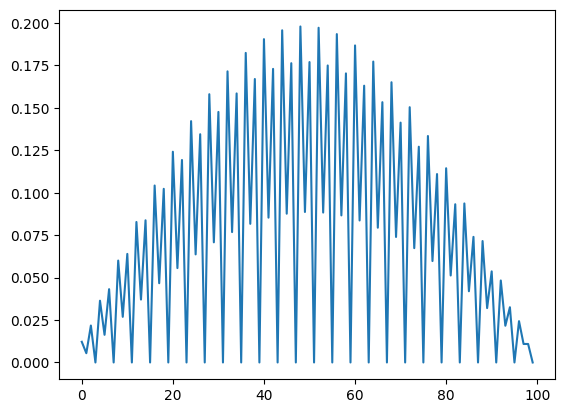

In [8]:
plt.plot(ground_state_pi.real)

In [9]:
u1 = np.array([0.176777 + 0.684653j, 1/np.sqrt(2)])
print(np.angle(u1))
print(2*np.arccos(1/4))
print(np.arccos(1/4))

[1.31811558 0.        ]
2.636232143305636
1.318116071652818


In [10]:
u1 = np.array([0.176777 + 0.684653j, 1/np.sqrt(2)])
print(np.angle(u1))
print(2*np.arccos(1/4))
print(np.arccos(1/4))

[1.31811558 0.        ]
2.636232143305636
1.318116071652818


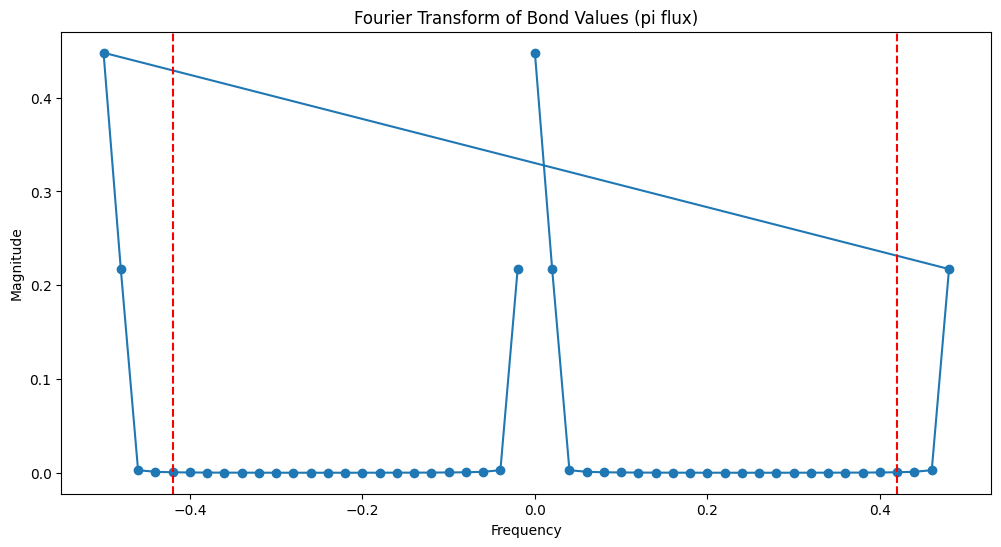

In [11]:
### fourier transform of bond values
bond_values_pi_ft = np.fft.fft(bond_values_pi)
frequencies = np.fft.fftfreq(len(bond_values_pi), d=1)
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(bond_values_pi_ft), marker='o')

plt.axvline(x=k_star/(2*np.pi), color='red', linestyle='--', label='k*')
plt.axvline(x=-k_star/(2*np.pi), color='red', linestyle='--')


plt.title('Fourier Transform of Bond Values (pi flux)')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()
